# Tutorial: estimating the AIA 1600/1700 Å degradation with the released CNN

A small CNN estimates how far the AIA 1600 Å and 1700 Å channels have dimmed, the factor **α** (1 = the level of SDOML-v2's corrected frames), from a single pair of full-disk images. It was trained only on SDOML-v2 frames dimmed by random α, never on the official degradation curve `DEG_COR`, which this notebook uses for comparison.

Steps (seconds on a laptop CPU with the local data):
1. load the released model;
2. get 11 held-out image pairs, one per year 2010–2020;
3. prepare them exactly as in training;
4. look at the data;
5. recover a known synthetic dimming;
6. estimate the real degradation, compare it with `DEG_COR`, and plot the released curve month by month;
7. correct an image.

Needs Python ≥ 3.10, torch, numpy, pandas, matplotlib, plus s3fs and numcodecs (`pip install s3fs numcodecs`) when the frames come from AWS. `sdoml_uv_dataset.py` and `models/` must sit next to this notebook.

In [1]:
from pathlib import Path
import hashlib, json, sys, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch

MODEL_FILE = Path("models/autocal_uv_1600_1700_refined_final.pt")
LOCAL_DATA = Path("../run/data")     # cubes written by notebook 01; if absent, frames are read from SDOML-v2 on AWS
SDOML_URL  = "s3://gov-nasa-hdrl-data1/contrib/fdl-sdoml/fdl-sdoml-v2/sdomlv2.zarr/"
REPORT_CSV = Path("results/eval_autocal_uv_1600_1700_refined/degradation_recovery.csv")   # optional cross-check
CURVE_DAILY   = Path("results/released_alpha_daily.csv")     # the released model on every pair, 2010-2020
CURVE_MONTHLY = Path("results/released_alpha_monthly.csv")   # the same by month, with uncertainties

sys.path.insert(0, ".")
from sdoml_uv_dataset import Autocalibration6, _disk_mask
torch.set_grad_enabled(False)          # inference only
print(f"python {sys.version.split()[0]}   torch {torch.__version__}   numpy {np.__version__}")

python 3.13.9   torch 2.9.1   numpy 2.3.5


## 1. Load the model

One file holds the weights and the settings they were trained with. `weights_only=True` loads tensors and plain values only. The fingerprint is the model's output for a fixed synthetic input: a different value means a wrong file or a broken install.

In [2]:
ck = torch.load(MODEL_FILE, map_location="cpu", weights_only=True)
CH = list(ck["channels"])
model = Autocalibration6(tuple(ck["input_shape"]), output_dim=len(CH), head=ck["head"], output_scale=ck["output_scale"])
model.load_state_dict(ck["model"]); model.eval()
for k in ("channels", "head", "min_alpha", "max_alpha", "subsample", "scale_map", "apodize_radius_px_512", "seed", "best_epoch"):
    print(f"{k:22s} {ck[k]}")

probe = torch.rand((1, 2, 256, 256), generator=torch.Generator().manual_seed(0)) * 0.5
fp = model(probe)[0].numpy()
assert np.allclose(fp, [0.07831066, 0.09314012], atol=1e-5), fp
print("fingerprint ok:", fp.round(6))

channels               ['1600A', '1700A']
head                   linear
min_alpha              0.01
max_alpha              1.25
subsample              2
scale_map              {'1600': 125.0, '1700': 1750.0}
apodize_radius_px_512  200.0
seed                   1
best_epoch             135
fingerprint ok: [0.078311 0.09314 ]


## 2. Eleven held-out image pairs

Target 15 November 00:00 UT of each year; the frames themselves were taken on 14 November between 23:53 and 23:59 UT. November and December were never trained on and never used to pick the checkpoint. `idx` is the frame's position in its year's SDOML-v2 array, `row` its position in the cubes of notebook 01, and `sha256` the first 16 hex digits of the hash of its float32 pixels.

In [3]:
PAIRS = pd.DataFrame([
{
"target": "2010-11-15",
"row": 171,
"idx_1600A": 24503,
"t_obs_1600A": "2010-11-14 23:59:54.570",
"deg_cor_1600A": 0.96216,
"exptime_1600A": 2.900747,
"sha256_1600A": "f745b1f5b21a0174",
"idx_1700A": 23393,
"t_obs_1700A": "2010-11-14 23:59:44.220",
"deg_cor_1700A": 1.00946,
"exptime_1700A": 1.000031,
"sha256_1700A": "32c583e12f756773"
},
{
"target": "2011-11-15",
"row": 308,
"idx_1600A": 38893,
"t_obs_1600A": "2011-11-14 23:59:54.570",
"deg_cor_1600A": 0.828296,
"exptime_1600A": 2.900745,
"sha256_1600A": "140e4653284272c0",
"idx_1700A": 38155,
"t_obs_1700A": "2011-11-14 23:59:44.210",
"deg_cor_1700A": 0.940635,
"exptime_1700A": 1.000028,
"sha256_1700A": "7be807ac01d5782c"
},
{
"target": "2012-11-15",
"row": 314,
"idx_1600A": 40744,
"t_obs_1600A": "2012-11-14 23:59:53.580",
"deg_cor_1600A": 0.653619,
"exptime_1600A": 2.901309,
"sha256_1600A": "f53cdd1cc9f1c3f1",
"idx_1700A": 39341,
"t_obs_1700A": "2012-11-14 23:54:07.210",
"deg_cor_1700A": 0.816307,
"exptime_1700A": 1.000588,
"sha256_1700A": "8fa65b6bda5b6108"
},
{
"target": "2013-11-15",
"row": 317,
"idx_1600A": 43878,
"t_obs_1600A": "2013-11-14 23:59:53.580",
"deg_cor_1600A": 0.63192,
"exptime_1600A": 2.900748,
"sha256_1600A": "6310e092e33a2d4d",
"idx_1700A": 42449,
"t_obs_1700A": "2013-11-14 23:54:07.210",
"deg_cor_1700A": 0.838423,
"exptime_1700A": 1.000036,
"sha256_1700A": "4c8e87b94de1bbd8"
},
{
"target": "2014-11-15",
"row": 310,
"idx_1600A": 40746,
"t_obs_1600A": "2014-11-14 23:53:53.570",
"deg_cor_1600A": 0.568485,
"exptime_1600A": 2.901308,
"sha256_1600A": "fc10dfe10d469226",
"idx_1700A": 36833,
"t_obs_1700A": "2014-11-14 23:54:07.210",
"deg_cor_1700A": 0.879369,
"exptime_1700A": 1.000598,
"sha256_1700A": "6d1c6fbfb0908650"
},
{
"target": "2015-11-15",
"row": 316,
"idx_1600A": 44068,
"t_obs_1600A": "2015-11-14 23:59:52.580",
"deg_cor_1600A": 0.506826,
"exptime_1600A": 2.900734,
"sha256_1600A": "7fbc32007d371c32",
"idx_1700A": 42600,
"t_obs_1700A": "2015-11-14 23:54:06.210",
"deg_cor_1700A": 0.876153,
"exptime_1700A": 1.000018,
"sha256_1700A": "9f538379380624ab"
},
{
"target": "2016-11-15",
"row": 311,
"idx_1600A": 43874,
"t_obs_1600A": "2016-11-14 23:59:52.580",
"deg_cor_1600A": 0.464167,
"exptime_1600A": 2.901279,
"sha256_1600A": "d720ebc86834e851",
"idx_1700A": 42444,
"t_obs_1700A": "2016-11-14 23:54:06.240",
"deg_cor_1700A": 0.870375,
"exptime_1700A": 1.00057,
"sha256_1700A": "8c4854cca9fe5070"
},
{
"target": "2017-11-15",
"row": 317,
"idx_1600A": 44706,
"t_obs_1600A": "2017-11-14 23:59:51.580",
"deg_cor_1600A": 0.434362,
"exptime_1600A": 2.900722,
"sha256_1600A": "ac989dab139043a4",
"idx_1700A": 43141,
"t_obs_1700A": "2017-11-14 23:54:05.220",
"deg_cor_1700A": 0.867192,
"exptime_1700A": 1.000014,
"sha256_1700A": "d391f3c909e5b476"
},
{
"target": "2018-11-15",
"row": 317,
"idx_1600A": 73936,
"t_obs_1600A": "2018-11-14 23:59:51.580",
"deg_cor_1600A": 0.394443,
"exptime_1600A": 2.900715,
"sha256_1600A": "ed7baa1b08ae80b3",
"idx_1700A": 66817,
"t_obs_1700A": "2018-11-14 23:54:05.220",
"deg_cor_1700A": 0.832715,
"exptime_1700A": 0.999998,
"sha256_1700A": "6bc2ee97c5c95582"
},
{
"target": "2019-11-15",
"row": 317,
"idx_1600A": 76039,
"t_obs_1600A": "2019-11-14 23:59:51.580",
"deg_cor_1600A": 0.349357,
"exptime_1600A": 2.900704,
"sha256_1600A": "633effceb5e7e5cc",
"idx_1700A": 68720,
"t_obs_1700A": "2019-11-14 23:54:05.220",
"deg_cor_1700A": 0.785318,
"exptime_1700A": 0.999994,
"sha256_1700A": "156877e0638c05ee"
},
{
"target": "2020-11-15",
"row": 318,
"idx_1600A": 74796,
"t_obs_1600A": "2020-11-14 23:59:51.580",
"deg_cor_1600A": 0.337238,
"exptime_1600A": 2.901288,
"sha256_1600A": "c9b6cbae0e6ff4c3",
"idx_1700A": 67598,
"t_obs_1700A": "2020-11-14 23:54:05.220",
"deg_cor_1700A": 0.771802,
"exptime_1700A": 1.000571,
"sha256_1700A": "bc47a725247b95a6"
}
])
PAIRS[["target", "t_obs_1600A", "t_obs_1700A", "deg_cor_1600A", "deg_cor_1700A"]]

,target,t_obs_1600A,t_obs_1700A,deg_cor_1600A,deg_cor_1700A
0,2010-11-15,2010-11-14 23:59:54.570,2010-11-14 23:59:44.220,0.962160,1.009460
1,2011-11-15,2011-11-14 23:59:54.570,2011-11-14 23:59:44.210,0.828296,0.940635
2,2012-11-15,2012-11-14 23:59:53.580,2012-11-14 23:54:07.210,0.653619,0.816307
3,2013-11-15,2013-11-14 23:59:53.580,2013-11-14 23:54:07.210,0.631920,0.838423
4,2014-11-15,2014-11-14 23:53:53.570,2014-11-14 23:54:07.210,0.568485,0.879369
5,2015-11-15,2015-11-14 23:59:52.580,2015-11-14 23:54:06.210,0.506826,0.876153
6,2016-11-15,2016-11-14 23:59:52.580,2016-11-14 23:54:06.240,0.464167,0.870375
7,2017-11-15,2017-11-14 23:59:51.580,2017-11-14 23:54:05.220,0.434362,0.867192
8,2018-11-15,2018-11-14 23:59:51.580,2018-11-14 23:54:05.220,0.394443,0.832715
9,2019-11-15,2019-11-14 23:59:51.580,2019-11-14 23:54:05.220,0.349357,0.785318


In [4]:
def read_local(year, ch, row):
    cube = np.load(LOCAL_DATA / f"{year}/sub_image_{ch}_{year}_512x512.npy", mmap_mode="r")
    return np.asarray(cube[row], dtype=np.float32)

def read_s3(year, ch, idx):
    """One frame from SDOML-v2 on AWS, anonymously: the array's small .zarray plus the one chunk (15 frames)
    that holds the frame. The year's .zattrs (every FITS keyword, hundreds of MB) is never downloaded."""
    import s3fs, numcodecs
    fs = s3fs.S3FileSystem(anon=True)
    base = SDOML_URL.replace("s3://", "").rstrip("/") + f"/{year}/{ch}"
    meta = json.loads(fs.cat(f"{base}/.zarray"))
    n, sep = meta["chunks"][0], meta.get("dimension_separator", ".")
    raw = fs.cat(f"{base}/{idx // n}{sep}0{sep}0")
    if meta.get("compressor"):
        raw = numcodecs.get_codec(meta["compressor"]).decode(raw)
    for f in reversed(meta.get("filters") or []):
        raw = numcodecs.get_codec(f).decode(raw)
    chunk = np.frombuffer(raw, dtype=meta["dtype"]).reshape(meta["chunks"], order=meta["order"])
    return np.asarray(chunk[idx % n], dtype=np.float32)

SOURCE = "local" if LOCAL_DATA.exists() else "aws"
frames, t0 = {}, time.time()
for _, p in PAIRS.iterrows():
    y = int(p.target[:4])
    for c in CH:
        f = read_local(y, c, p.row) if SOURCE == "local" else read_s3(y, c, p[f"idx_{c}"])
        assert hashlib.sha256(f.tobytes()).hexdigest()[:16] == p[f"sha256_{c}"], f"{p.target} {c}: not the expected frame"
        frames[(p.target, c)] = f
print(f"{len(frames)} frames from {SOURCE} in {time.time() - t0:.1f} s; all hashes match")

22 frames from local in 0.0 s; all hashes match


## 3. Prepare the input exactly as in training

1. take every second pixel, 512² → 256² (`[::2]`);
2. divide by 125 (1600 Å) and 1750 (1700 Å): the paper's constants converted to SDOML-v2 units (v2 averages 2×2 blocks where v1 summed them, so v1 = 4 × v2);
3. set everything outside r = 100 px to zero (the paper's apodization);
4. mirror left–right, as the report's evaluation does for every frame of the `DEG_COR` test and the α sweep, so the numbers below match the report's.

The function follows `SdomlUVDataset.__getitem__` step by step; when the local cubes exist, the cell checks that the two agree exactly.

In [5]:
MASK = _disk_mask(512 // ck["subsample"], ck["apodize_radius_px_512"] / ck["subsample"])

def prepare(pair, mirror=True):
    """pair: {channel: 512x512 frame in DN/s} -> network input of shape (1, 2, 256, 256)"""
    s = ck["subsample"]
    img = np.stack([np.asarray(pair[c][::s, ::s], dtype=np.float32) for c in CH], axis=0)
    for k, c in enumerate(CH):
        img[k] /= float(ck["scale_map"][c[:-1]])
    img *= MASK[None, :, :]
    x = torch.from_numpy(img)
    return (torch.flip(x, [2]) if mirror else x)[None]

if SOURCE == "local":                  # same result as the training code?
    from sdoml_uv_dataset import SdomlUVDataset
    ds = SdomlUVDataset(data_root=str(LOCAL_DATA), channels=CH, years=[2015], months=[11], subsample=ck["subsample"],
                        scaling=True, scale_map=ck["scale_map"], normalization=0, apodize=True,
                        apodize_radius_px_512=ck["apodize_radius_px_512"], threshold_black=False,
                        flip_images=True, synthetic_dimming=False, size_tag="512x512")
    i = [str(t)[:10] for t in ds.timestamps()].index("2015-11-14")
    same = torch.equal(ds[i][2], prepare({c: frames[("2015-11-15", c)] for c in CH})[0])
    print("identical to SdomlUVDataset:", same); assert same

identical to SdomlUVDataset: True


## 4. Look at the data

SDOML-v2 stores frames already divided by `DEG_COR`, so their brightness stays flat over the mission. Multiplying by `DEG_COR` gives the frame as observed. Each channel uses one display scale; by 2020, 1600 Å has lost two thirds of its signal.

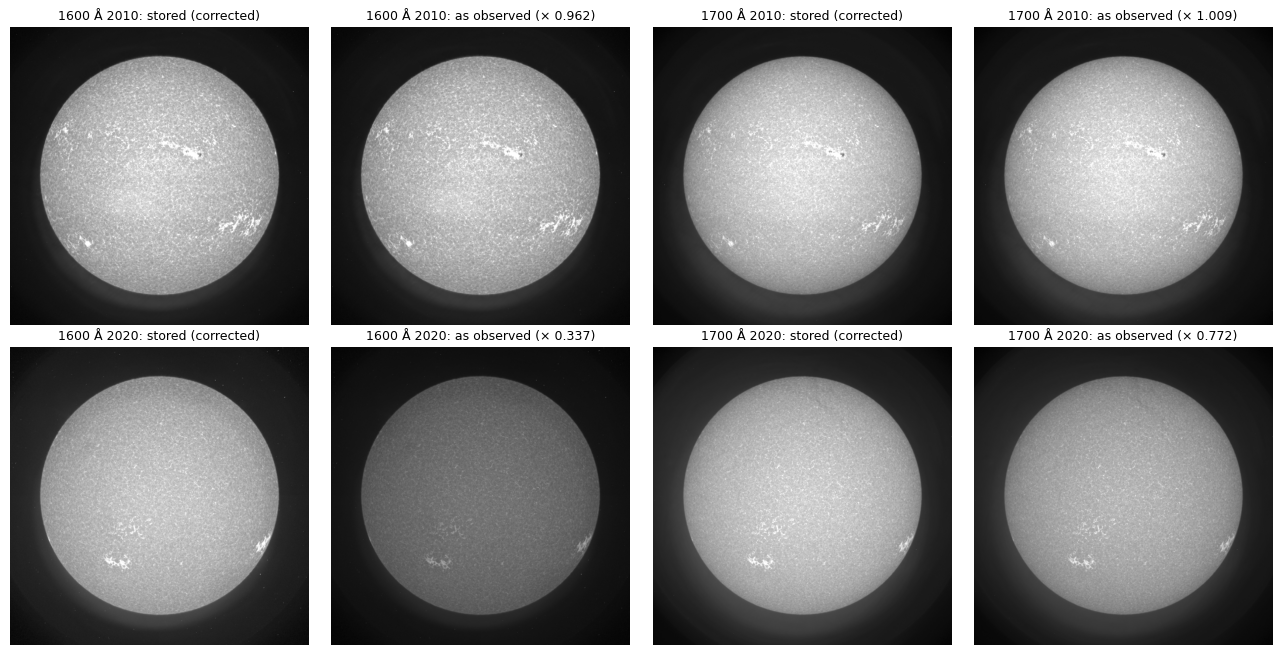

In [6]:
fig, ax = plt.subplots(2, 4, figsize=(13, 6.6))
for r, t in enumerate(("2010-11-15", "2020-11-15")):
    p = PAIRS.set_index("target").loc[t]
    for k, c in enumerate(CH):
        vmax = np.sqrt(np.percentile(frames[("2010-11-15", c)], 99.5))
        for j, (img, lab) in enumerate([(frames[(t, c)], "stored (corrected)"),
                                        (frames[(t, c)] * p[f"deg_cor_{c}"], f"as observed (× {p[f'deg_cor_{c}']:.3f})")]):
            a = ax[r, 2 * k + j]
            a.imshow(np.sqrt(np.clip(img, 0, None)), origin="lower", cmap="gray", vmin=0, vmax=vmax)
            a.set_title(f"{c[:-1]} Å {t[:4]}: {lab}", fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

## 5. A synthetic test

Dim the stored pairs by a known α, here 0.9 for 1600 Å and 0.6 for 1700 Å, and read α back.

In [7]:
alpha = np.array([0.9, 0.6], dtype=np.float32)
est = np.array([model(prepare({c: frames[(t, c)] * alpha[k] for k, c in enumerate(CH)}))[0].numpy() for t in PAIRS.target])
err = est - alpha
print("true alpha:", alpha)
print(pd.DataFrame({"date": PAIRS.target, **{f"alpha_hat {c[:-1]}": est[:, k] for k, c in enumerate(CH)}}).round(4).to_string(index=False))
print("mean |error|: " + ", ".join(f"{c[:-1]} Å {np.abs(err[:, k]).mean():.4f}" for k, c in enumerate(CH)))

true alpha: [0.9 0.6]
      date  alpha_hat 1600  alpha_hat 1700
2010-11-15          0.8789          0.5926
2011-11-15          0.8832          0.5927
2012-11-15          0.8923          0.6058
2013-11-15          0.9095          0.6188
2014-11-15          0.9192          0.6101
2015-11-15          0.9253          0.6039
2016-11-15          0.9162          0.6012
2017-11-15          0.8983          0.5962
2018-11-15          0.9113          0.6010
2019-11-15          0.9347          0.6090
2020-11-15          0.8757          0.5886
mean |error|: 1600 Å 0.0171, 1700 Å 0.0073


Single frames scatter around the mean. Over 96 frames of the mission at α = 0.9, the frame-to-frame standard deviation is 0.015 for 1600 Å and 0.009 for 1700 Å, and the mean bias is +0.004 and +0.001 (the data behind the report's Fig. 3).

## 6. Frames as observed: recovering `DEG_COR`

For each pair, the as-observed frames (stored × `DEG_COR`) go into the network, which returns α̂. The network never saw `DEG_COR` or the date. Note that this checks recovery of a known dimming on real solar images; it does not independently validate the official curve, because the stored frames themselves were corrected with it.

In [8]:
res = []
for _, p in PAIRS.iterrows():
    obs = {c: frames[(p.target, c)] * p[f"deg_cor_{c}"] for c in CH}
    a_hat = model(prepare(obs))[0].numpy()
    res.append({"date": p.t_obs_1600A[:10], **{f"DEG_COR {c[:-1]}": p[f"deg_cor_{c}"] for c in CH},
                **{f"alpha_hat {c[:-1]}": float(a_hat[k]) for k, c in enumerate(CH)}})
res = pd.DataFrame(res)
for c in CH:
    res[f"error {c[:-1]}"] = res[f"alpha_hat {c[:-1]}"] - res[f"DEG_COR {c[:-1]}"]
display(res.round(4))
print("mean |error|: " + ", ".join(f"{c[:-1]} Å {res[f'error {c[:-1]}'].abs().mean():.4f}" for c in CH))

if REPORT_CSV.exists():                # the same frames in the report's evaluation
    rep = pd.read_csv(REPORT_CSV); rep["date"] = rep.t_obs.str[:10]
    m = res.merge(rep, on="date")
    d = max(np.abs(m[f"alpha_hat {c[:-1]}"] - m[f"pred_best_{c}"]).max() for c in CH)
    print(f"largest difference to the report's per-frame values: {d:.1e}")
    assert d < 1e-5
    h = rep[rep.split == "holdout"]
    print(f"for comparison, the report's {len(h)} held-out pairs: mean |error| "
          + ", ".join(f"{c[:-1]} Å {(h[f'pred_best_{c}'] - h[f'deg_cor_{c}']).abs().mean():.4f}" for c in CH))

obs = {c: frames[("2020-11-15", c)] * PAIRS.iloc[-1][f"deg_cor_{c}"] for c in CH}
print("2020 pair without mirroring:", model(prepare(obs, mirror=False))[0].numpy().round(4))

,date,DEG_COR 1600,DEG_COR 1700,alpha_hat 1600,alpha_hat 1700,error 1600,error 1700
0,2010-11-14,0.9622,1.0095,0.9453,1.0019,-0.0169,-0.0075
1,2011-11-14,0.8283,0.9406,0.8090,0.9212,-0.0193,-0.0194
2,2012-11-14,0.6536,0.8163,0.6486,0.8188,-0.0050,0.0025
3,2013-11-14,0.6319,0.8384,0.6388,0.8666,0.0069,0.0282
4,2014-11-14,0.5685,0.8794,0.5844,0.8874,0.0159,0.0080
5,2015-11-14,0.5068,0.8762,0.5280,0.8812,0.0212,0.0050
6,2016-11-14,0.4642,0.8704,0.4756,0.8780,0.0114,0.0076
7,2017-11-14,0.4344,0.8672,0.4393,0.8631,0.0050,-0.0041
8,2018-11-14,0.3944,0.8327,0.3991,0.8294,0.0046,-0.0033
9,2019-11-14,0.3494,0.7853,0.3645,0.7942,0.0151,0.0089


mean |error|: 1600 Å 0.0118, 1700 Å 0.0096
largest difference to the report's per-frame values: 2.6e-06
for comparison, the report's 660 held-out pairs: mean |error| 1600 Å 0.0094, 1700 Å 0.0072
2020 pair without mirroring: [0.3256 0.7601]


### The released curve, month by month

Eleven points show little of the curve. `results/released_alpha_monthly.csv` holds the released model's α̂ for every month of 2010–2020, from all 3,826 pairs: the median, the 16th–84th percentile of single days, and the spread over three seeds × two checkpoints. Months are split where `DEG_COR` steps, so no month mixes two calibration levels; `results/released_alpha_daily.csv` has every pair. With the local data, the cell also runs the model live on one pair per month (the one targeted at the 15th) and checks it against the file; without it, the 11 pairs above are checked.

127 live pairs; largest difference to the shipped daily file: 4.1e-06


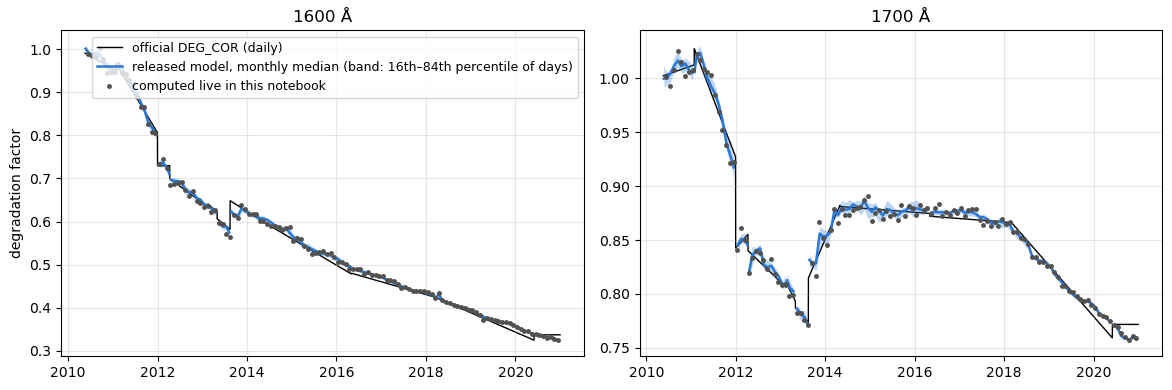

channel             t_first              t_last  n_frames  alpha_median  alpha_p16  alpha_p84  alpha_ckpt_min  alpha_ckpt_max
  1600A 2020-11-01 23:59:51 2020-11-30 23:59:51        30        0.3276     0.3257     0.3285          0.3228          0.3276
  1600A 2020-12-01 23:59:51 2020-12-30 23:59:51        30        0.3248     0.3218     0.3272          0.3211          0.3248
  1700A 2020-11-01 23:59:51 2020-11-30 23:59:51        30        0.7597     0.7586     0.7620          0.7557          0.7597
  1700A 2020-12-01 23:59:51 2020-12-30 23:59:51        30        0.7580     0.7563     0.7604          0.7530          0.7580


In [9]:
daily = pd.read_csv(CURVE_DAILY, comment="#", parse_dates=["t_obs_1600A"])
monthly = pd.read_csv(CURVE_MONTHLY, comment="#", parse_dates=["t_first", "t_last", "t_mid"])
daily["t"] = daily.t_obs_1600A.dt.floor("s")

live = pd.DataFrame({"t": pd.to_datetime(PAIRS.t_obs_1600A).dt.floor("s"), **{c: res[f"alpha_hat {c[:-1]}"].values for c in CH}})
if SOURCE == "local":                  # one live pair per month: the frames targeted at the 15th
    rows = []
    for y in range(2010, 2021):
        ix = pd.read_csv(LOCAL_DATA / f"{y}/index_{y}.csv")
        for r in np.flatnonzero(ix.target.str[8:10].values == "15"):
            pair = {c: read_local(y, c, int(r)) * float(ix[f"degcor_{c}"].iloc[r]) for c in CH}
            a_hat = model(prepare(pair))[0].numpy()
            rows.append({"t": pd.Timestamp(ix.t_obs_1600A.iloc[r]).floor("s"), **{c: float(a_hat[k]) for k, c in enumerate(CH)}})
    live = pd.DataFrame(rows)
chk = live.merge(daily, on="t")
assert len(chk) == len(live)
d = max(np.abs(chk[c] - chk[f"alpha_hat_{c}"]).max() for c in CH)
print(f"{len(live)} live pairs; largest difference to the shipped daily file: {d:.1e}")
assert d < 1e-5

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for k, c in enumerate(CH):
    mc = monthly[monthly.channel == c]
    ax[k].plot(daily.t, daily[f"deg_cor_{c}"], color="k", lw=1, zorder=1, label="official DEG_COR (daily)")
    for s, g in mc.groupby("segment"):            # one line per stretch between two DEG_COR steps
        ax[k].fill_between(g.t_mid, g.alpha_p16, g.alpha_p84, color="#2a78d6", alpha=0.3, lw=0, zorder=2)
        ax[k].plot(g.t_mid, g.alpha_median, color="#2a78d6", lw=1.8, zorder=3, label="released model, monthly median (band: 16th–84th percentile of days)" if s == 0 else None)
    ax[k].plot(live.t, live[c], "o", color="#52514e", ms=2.5, zorder=4, label="computed live in this notebook")
    ax[k].set_title(f"{c[:-1]} Å"); ax[k].grid(alpha=0.3)
ax[0].set_ylabel("degradation factor"); ax[0].legend(fontsize=9)
plt.tight_layout(); plt.show()
print(monthly.groupby("channel").tail(2)[["channel", "t_first", "t_last", "n_frames", "alpha_median", "alpha_p16", "alpha_p84", "alpha_ckpt_min", "alpha_ckpt_max"]].round(4).to_string(index=False))

## 7. Correct an image

Dividing the observed frame by α̂ undoes the degradation. Compare with the stored frame, which was corrected with the official factor.

In [10]:
p = PAIRS.iloc[-1]
obs = {c: frames[(p.target, c)] * p[f"deg_cor_{c}"] for c in CH}
a_hat = model(prepare(obs))[0].numpy()
for k, c in enumerate(CH):
    corrected = obs[c] / a_hat[k]
    disk = MASK > 0                                              # on-disk pixels of the 256 grid
    ratio = corrected[::2, ::2][disk] / frames[(p.target, c)][::2, ::2][disk]
    print(f"{c[:-1]} Å {p.target}: corrected / stored on the disk = {ratio.mean():.4f}  (= DEG_COR / alpha_hat)")

1600 Å 2020-11-15: corrected / stored on the disk = 1.0267  (= DEG_COR / alpha_hat)
1700 Å 2020-11-15: corrected / stored on the disk = 1.0144  (= DEG_COR / alpha_hat)


## Pitfalls

- **Input contract.** The model expects frames processed like SDOML-v2 (Sun rescaled to 976″, 4.8″ per pixel, 512², DN/s after exposure normalisation), as observed, in the channel order [1600, 1700], then the four steps of section 3. Frames from another pipeline must be converted the same way, or α̂ means nothing.
- **α range.** Training used α ∈ [0.01, 1.25]; outside it the model extrapolates.
- **The shipped curve** (`results/released_alpha_*.csv`) covers SDOML-v2 up to 2020. It recovers `DEG_COR`; it is not an independent calibration.
- **Mirroring** belongs to the evaluation protocol. For new data either way gives nearly the same α̂ (section 6 prints both); do not mix the two in one study.
- **Apple-silicon GPU (MPS).** Never copy tensors with `non_blocking=True` (pytorch#139550), and keep every tensor below 4 GB (pytorch#149325): run large batches in chunks.
- **Units.** The paper's scale constants (500 and 7000) are in SDOML-v1 units; in v2 they are 125 and 1750.

## Next steps

Rebuild the full data set with notebook 01 in `../run/` (it is saved set to 2020, which took 42 min; all years should take about 7 h), train with 02b (about 38 min on an Apple-silicon GPU), and evaluate with 03. The method is that of Dos Santos et al. 2021, A&A 648, A53; the data are SDOML-v2 (Galvez et al. 2019, ApJS 242, 7).